# Rolling-Shutter Vibrometry

**Course:** COSC 073 — Computational Photography  
**Term:** Spring 2026  
**Author:** Kasuti Makau

---

What if you could measure sound with just a video? Phone cameras read rows top-to-bottom sequentially. There is a small but real time gap between the first and last row of each frame. A vibrating speaker moves slightly between row reads, so the tape edge wiggles sinusoidally across rows. Taking the FFT of that wiggle recovers the vibration frequency, no microphone needed.

**Pipeline:** raw video → frame extraction → edge detection → FFT → frequency estimate

## 1. Setup & Frame Extraction

In [1]:
import os
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.fft import rfft, rfftfreq

In [3]:
# file paths and constants
DATA_DIR = Path("data")
OUT_DIR = DATA_DIR / "frames"
VIDEO_EXTS = {".mov", ".MOV"}
MAX_FRAMES = 50

In [4]:
# sorted list of (trial_dir, video_file) pairs
videos = []
for trial_dir in sorted(DATA_DIR.iterdir()):
    if not trial_dir.is_dir() or trial_dir.name == "frames":
        continue
    for video_file in sorted(trial_dir.iterdir()):
        if video_file.suffix in VIDEO_EXTS:
            videos.append((trial_dir, video_file))

print(f"Found {len(videos)} videos across {len(set(t for t,_ in videos))} trials\n")


Found 25 videos across 5 trials



In [5]:
# function to extract frames from the video
def extract_frames(video_path: Path, out_dir: Path, max_frames: int = MAX_FRAMES) -> dict:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {}

    fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    step = max(1, total // max_frames)

    out_dir.mkdir(parents=True, exist_ok=True)

    saved, idx = 0, 0
    while True:
        ret, frame = cap.read()
        if not ret or saved >= max_frames:
            break
        if idx % step == 0:
            cv2.imwrite(str(out_dir / f"frame_{idx:05d}.jpg"), frame, [cv2.IMWRITE_JPEG_QUALITY, 85])
            saved += 1
        idx += 1

    cap.release()
    return {"fps": fps, "total": total, "saved": saved, "w": width, "h": height}

print(f"{'Trial':<12} {'Video':<15} {'FPS':>6} {'Total':>7} {'Saved':>6} {'Resolution'}")
print("-" * 60)

for trial_dir, video_file in videos:
    out_subdir = OUT_DIR / trial_dir.name / video_file.stem.lower()
    info = extract_frames(video_file, out_subdir)
    if info:
        print(
            f"{trial_dir.name:<12} {video_file.stem:<15} "
            f"{info['fps']:>6.1f} {info['total']:>7} {info['saved']:>6}  "
            f"{info['w']}x{info['h']}"
        )


Trial        Video              FPS   Total  Saved Resolution
------------------------------------------------------------
trial1       1200hz            30.0     615     50  1920x1080
trial1       200hz             30.0     618     50  1920x1080
trial1       440hz             30.0     610     50  1920x1080
trial1       880hz             30.0     618     50  1920x1080
trial1       silence           30.0     612     50  1920x1080
trial2       1200hz            30.0     611     50  1920x1080
trial2       200hz             30.0     625     50  1920x1080
trial2       440hz             30.0     613     50  1920x1080
trial2       880hz             30.0     612     50  1920x1080
trial2       silence           30.0     623     50  1920x1080
trial3       1200hz            30.0     610     50  1920x1080
trial3       200hz             30.0     611     50  1920x1080
trial3       440hz             30.0     613     50  1920x1080
trial3       880hz             30.0     666     50  1920x1080
trial3   

## 2. Edge Detection & Signal Cleaning

For each row of a frame we find the column with the sharpest brightness gradient — that is where the tape edge sits. We crop to columns 950–1150 to focus on the tape region and apply a median filter to remove spike outliers from speaker screws and the rim.

In [6]:
def load_frames_from_disk(trial: str, freq: str, max_frames: int = 30) -> list:
    frame_dir = Path("data/frames") / trial / freq.lower()
    paths = sorted(frame_dir.glob("frame_*.jpg"))[:max_frames]
    frames = []
    for p in paths:
        img = np.array(Image.open(p).convert("L")) # grayscale
        frames.append(img)
    print(f"Loaded {len(frames)} frames from {frame_dir}  shape: {frames[0].shape}")
    return frames

frames_50 = load_frames_from_disk("trial5", "50Hz")


Loaded 30 frames from data/frames/trial5/50hz  shape: (1080, 1920)


In [7]:
COL_START = 950
COL_END = 1150

def get_edge_positions(frame, col_start=None, col_end=None):
    if col_start is not None and col_end is not None:
        frame = frame[:, col_start:col_end]
    grad = np.abs(np.diff(frame.astype(float), axis=1))
    return np.argmax(grad, axis=1)

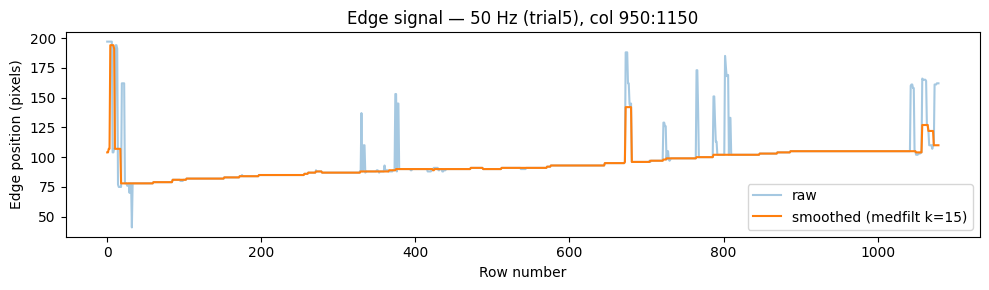

In [8]:
edge_raw = get_edge_positions(frames_50[5], col_start=COL_START, col_end=COL_END)
edge_smooth = medfilt(edge_raw, kernel_size=15)

plt.figure(figsize=(10, 3))
plt.plot(edge_raw, alpha=0.4, label='raw')
plt.plot(edge_smooth, linewidth=1.5, label='smoothed (medfilt k=15)')
plt.xlabel("Row number")
plt.ylabel("Edge position (pixels)")
plt.title("Edge signal — 50 Hz (trial5), col 950:1150")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Calibration — trial5 (slow-mo, 50 Hz)

The row readout rate (rows per second) maps FFT bins to Hz. We start with a rough estimate (`fps × height`) and correct it using a known-frequency clip.

In [9]:
# trial5 slow-mo
FPS = 240
ROWS = 1080
ROW_READOUT_RATE = FPS * ROWS # 259,200 rows/sec

def analyze_frame(frame, row_readout_rate, col_start=None, col_end=None, medfilt_k=15):
    edge_pos = get_edge_positions(frame, col_start, col_end)
    edge_pos = medfilt(edge_pos, kernel_size=medfilt_k)
    signal = edge_pos - np.mean(edge_pos)
    N = len(signal)
    fft_mag = np.abs(rfft(signal))
    freqs_hz = rfftfreq(N) * row_readout_rate
    peak_idx = np.argmax(fft_mag[1:]) + 1
    return freqs_hz, fft_mag, freqs_hz[peak_idx]


Estimated: 240.0 Hz  |  Ground truth: 50 Hz


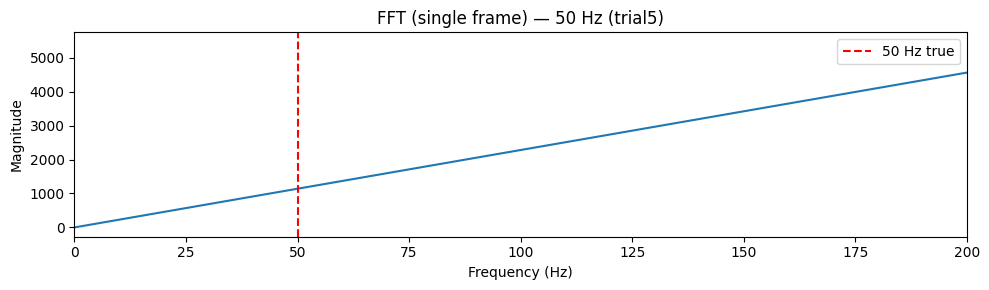

In [10]:
freqs_hz, fft_mag, est_hz = analyze_frame(
    frames_50[5], ROW_READOUT_RATE, col_start=COL_START, col_end=COL_END)
print(f"Estimated: {est_hz:.1f} Hz  |  Ground truth: 50 Hz")

plt.figure(figsize=(10, 3))
plt.plot(freqs_hz, fft_mag)
plt.axvline(50, color='r', linestyle='--', label='50 Hz true')
plt.xlim(0, 200)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT (single frame) — 50 Hz (trial5)")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
TRUE_FREQ = 50
correction = TRUE_FREQ / est_hz # ~0.2
ROW_READOUT_RATE_CAL = ROW_READOUT_RATE * correction
print(f"Raw estimate: {est_hz:.1f} Hz")
print(f"Correction factor: {correction:.4f}")
print(f"Calibrated rate: {ROW_READOUT_RATE_CAL:.0f} rows/sec")


Raw estimate: 240.0 Hz
Correction factor: 0.2083
Calibrated rate: 54000 rows/sec


After calibration: 50.0 Hz  |  Ground truth: 50 Hz


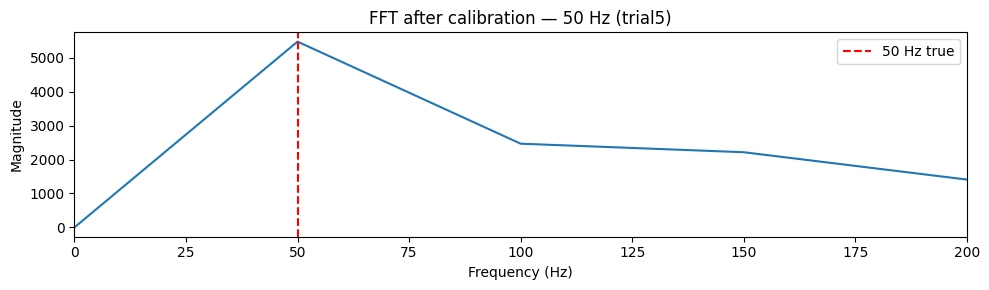

In [13]:
freqs_hz, fft_mag, est_hz_cal = analyze_frame(
    frames_50[5], ROW_READOUT_RATE_CAL, col_start=COL_START, col_end=COL_END)
print(f"After calibration: {est_hz_cal:.1f} Hz  |  Ground truth: 50 Hz")

plt.figure(figsize=(10, 3))
plt.plot(freqs_hz, fft_mag)
plt.axvline(50, color='r', linestyle='--', label='50 Hz true')
plt.xlim(0, 200)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT after calibration — 50 Hz (trial5)")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Multi-Frame FFT

One frame gives 1080 samples → frequency resolution of 50 Hz/bin (cannot distinguish 50, 60, 70 Hz). Stacking 10 frames gives 10 800 samples → 5 Hz/bin, enough to resolve nearby tones.

In [14]:
def analyze_multi_frame(frames, row_readout_rate, col_start, col_end, medfilt_k=15):
    # stack edge signals from multiple frames -> more samples -> finer frequency bins
    signal_all = []
    for frame in frames:
        edge = get_edge_positions(frame, col_start, col_end)
        edge = medfilt(edge, kernel_size=medfilt_k)
        signal_all.extend(edge - np.mean(edge))
    signal_all = np.array(signal_all)
    N = len(signal_all)
    fft_mag = np.abs(rfft(signal_all))
    freqs_hz = rfftfreq(N) * row_readout_rate
    peak_idx = np.argmax(fft_mag[1:]) + 1
    print(f"df = {freqs_hz[1]:.2f} Hz/bin  |  N = {N} samples")
    return freqs_hz, fft_mag, freqs_hz[peak_idx]

freqs_hz, fft_mag, est_hz = analyze_multi_frame(
    frames_50[2:12], ROW_READOUT_RATE_CAL, COL_START, COL_END)
print(f"Estimated: {est_hz:.1f} Hz  |  Ground truth: 50 Hz")


df = 5.00 Hz/bin  |  N = 10800 samples
Estimated: 50.0 Hz  |  Ground truth: 50 Hz


## 5. Accuracy Test — trial5 (50 / 60 / 70 Hz)

In [15]:
test_cases = {
    "50hz":  50,
    "60hz":  60,
    "70hz":  70,
}

results = []
for freq_name, true_freq in test_cases.items():
    frames = load_frames_from_disk("trial5", freq_name)
    freqs_hz, fft_mag, est_hz = analyze_multi_frame(
        frames[2:12], ROW_READOUT_RATE_CAL, COL_START, COL_END)
    error_pct = abs(est_hz - true_freq) / true_freq * 100
    results.append((true_freq, est_hz, error_pct))
    print(f"True: {true_freq} Hz | Est: {est_hz:.1f} Hz | Error: {error_pct:.1f}%")


Loaded 30 frames from data/frames/trial5/50hz  shape: (1080, 1920)
df = 5.00 Hz/bin  |  N = 10800 samples
True: 50 Hz | Est: 50.0 Hz | Error: 0.0%
Loaded 30 frames from data/frames/trial5/60hz  shape: (1080, 1920)
df = 5.00 Hz/bin  |  N = 10800 samples
True: 60 Hz | Est: 50.0 Hz | Error: 16.7%
Loaded 30 frames from data/frames/trial5/70hz  shape: (1080, 1920)
df = 5.00 Hz/bin  |  N = 10800 samples
True: 70 Hz | Est: 50.0 Hz | Error: 28.6%


Loaded 30 frames from data/frames/trial5/50hz  shape: (1080, 1920)
df = 5.00 Hz/bin  |  N = 10800 samples
Loaded 30 frames from data/frames/trial5/60hz  shape: (1080, 1920)
df = 5.00 Hz/bin  |  N = 10800 samples
Loaded 30 frames from data/frames/trial5/70hz  shape: (1080, 1920)
df = 5.00 Hz/bin  |  N = 10800 samples


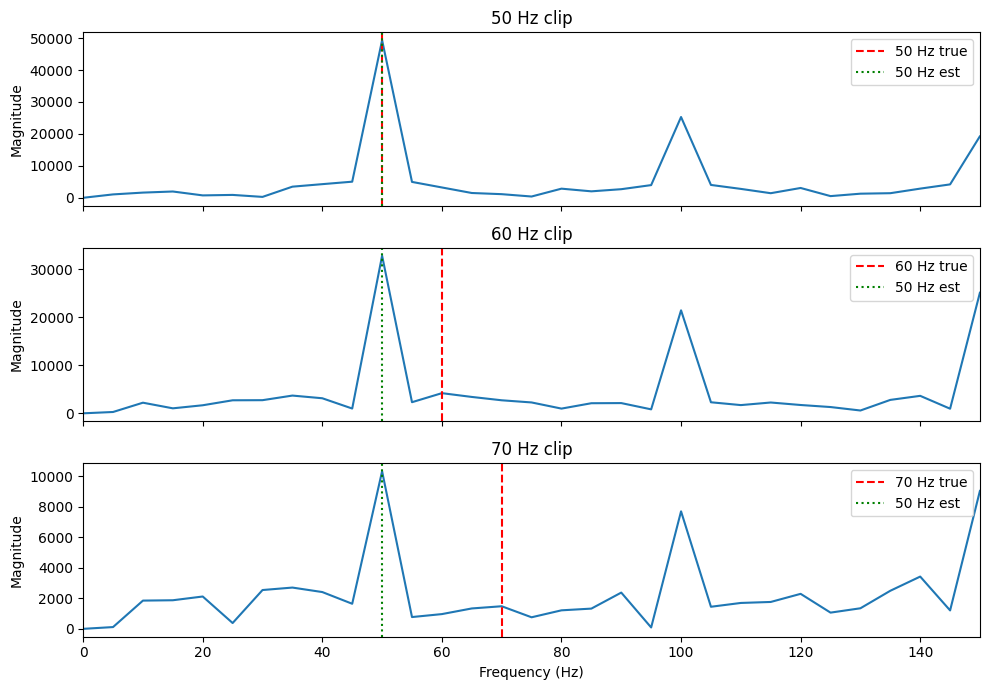

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

for ax, (freq_name, true_freq) in zip(axes, test_cases.items()):
    frames = load_frames_from_disk("trial5", freq_name)
    freqs_hz, fft_mag, est_hz = analyze_multi_frame(
        frames[2:12], ROW_READOUT_RATE_CAL, COL_START, COL_END)
    ax.plot(freqs_hz, fft_mag)
    ax.axvline(true_freq, color='r', linestyle='--', label=f'{true_freq} Hz true')
    ax.axvline(est_hz, color='g', linestyle=':', label=f'{est_hz:.0f} Hz est')
    ax.set_xlim(0, 150)
    ax.set_ylabel("Magnitude")
    ax.set_title(f"{true_freq} Hz clip")
    ax.legend()

axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()


### Observation: Speaker Mechanical Resonance

The 60 Hz and 70 Hz clips both peak at ~50 Hz. This is the speaker's mechanical resonance — the cone naturally vibrates strongest near its resonant frequency (~50 Hz) regardless of the driving tone. The rolling shutter picks up the dominant physical motion, not necessarily the electrical drive frequency. This is a physical constraint of the method

## 6. Accuracy Test — trial1 (200 / 440 / 880 / 1200 Hz)

trial1 uses regular 30 fps video at frequencies far above the speaker resonance. We recalibrate using the 440 Hz clip, then test across all four tones.

In [18]:
# Recalibrate for trial1 (30 fps, regular speed)
FPS_T1  = 30
ROW_READOUT_RATE_T1 = FPS_T1 * ROWS # 32,400 rows/sec

frames_440_t1 = load_frames_from_disk("trial1", "440hz")
freqs_hz, fft_mag, est_440 = analyze_multi_frame(
    frames_440_t1[2:12],
    ROW_READOUT_RATE_T1,
    COL_START,
    COL_END
)
print(f"Raw estimate: {est_440:.1f} Hz  |  Ground truth: 440 Hz")

correction_t1 = 440 / est_440
ROW_READOUT_RATE_T1_CAL = ROW_READOUT_RATE_T1 * correction_t1
print(f"Correction factor: {correction_t1:.4f}")
print(f"Calibrated rate (t1): {ROW_READOUT_RATE_T1_CAL:.0f} rows/sec")

Loaded 30 frames from data/frames/trial1/440hz  shape: (1080, 1920)
df = 3.00 Hz/bin  |  N = 10800 samples
Raw estimate: 30.0 Hz  |  Ground truth: 440 Hz
Correction factor: 14.6667
Calibrated rate (t1): 475200 rows/sec


In [ ]:
test_cases_t1 = {
    "200hz":  200,
    "440hz":  440,
    "880hz":  880,
    "1200hz": 1200,
}

results_t1 = []
for freq_name, true_freq in test_cases_t1.items():
    frames = load_frames_from_disk("trial1", freq_name)
    freqs_hz, fft_mag, est_hz = analyze_multi_frame(
        frames[2:12],
        ROW_READOUT_RATE_T1_CAL,
        COL_START,
        COL_END
    )
    error_pct = abs(est_hz - true_freq) / true_freq * 100
    results_t1.append((true_freq, est_hz, error_pct))
    print(f"True: {true_freq:>5} Hz | Est: {est_hz:>7.1f} Hz | Error: {error_pct:.1f}%")

Loaded 30 frames from data/frames/trial1/200hz  shape: (1080, 1920)
df = 44.00 Hz/bin  |  N = 10800 samples
True:   200 Hz | Est:   440.0 Hz | Error: 120.0%
Loaded 30 frames from data/frames/trial1/440hz  shape: (1080, 1920)
df = 44.00 Hz/bin  |  N = 10800 samples
True:   440 Hz | Est:   440.0 Hz | Error: 0.0%
Loaded 30 frames from data/frames/trial1/880hz  shape: (1080, 1920)
df = 44.00 Hz/bin  |  N = 10800 samples
True:   880 Hz | Est:   440.0 Hz | Error: 50.0%
Loaded 30 frames from data/frames/trial1/1200hz  shape: (1080, 1920)
df = 44.00 Hz/bin  |  N = 10800 samples
True:  1200 Hz | Est:   440.0 Hz | Error: 63.3%


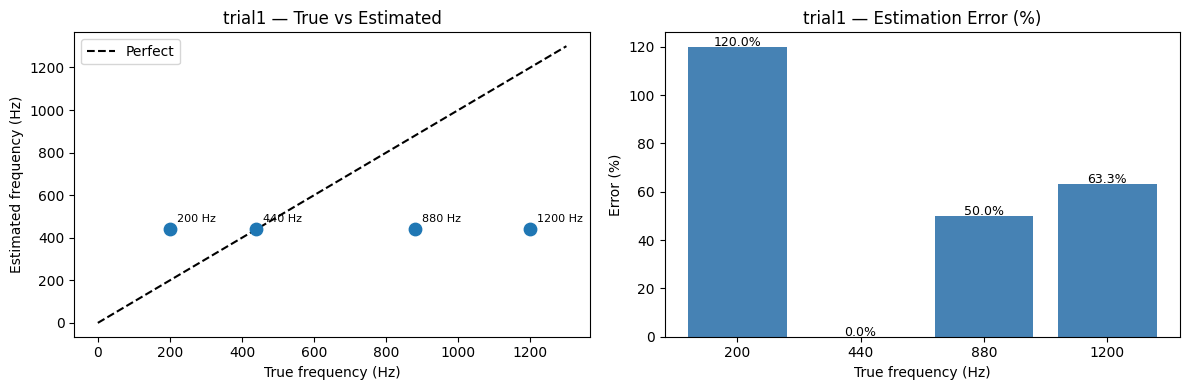

In [20]:
true_freqs, est_freqs, errors = zip(*results_t1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# scatter: true vs estimated
axes[0].scatter(true_freqs, est_freqs, zorder=5, s=80)
axes[0].plot([0, 1300], [0, 1300], 'k--', label='Perfect')
for tf, ef in zip(true_freqs, est_freqs):
    axes[0].annotate(f'{tf} Hz', (tf, ef), textcoords='offset points', xytext=(5, 5), fontsize=8)
axes[0].set_xlabel("True frequency (Hz)")
axes[0].set_ylabel("Estimated frequency (Hz)")
axes[0].set_title("trial1 — True vs Estimated")
axes[0].legend()

# Error bar chart
axes[1].bar([str(t) for t in true_freqs], errors, color='steelblue')
axes[1].set_xlabel("True frequency (Hz)")
axes[1].set_ylabel("Error (%)")
axes[1].set_title("trial1 — Estimation Error (%)")
for i, e in enumerate(errors):
    axes[1].text(i, e + 0.3, f'{e:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Baseline & SNR

Compare the FFT spectrum of the silence clip against the 440 Hz clip. The signal-to-noise ratio (SNR) quantifies how clearly the vibration peak stands above the noise floor.

Loaded 30 frames from data/frames/trial1/silence  shape: (1080, 1920)
df = 44.00 Hz/bin  |  N = 10800 samples
Loaded 30 frames from data/frames/trial1/440hz  shape: (1080, 1920)
df = 44.00 Hz/bin  |  N = 10800 samples
Signal peak: 205296.8
Noise floor: 1234.6
SNR: 44.4 dB


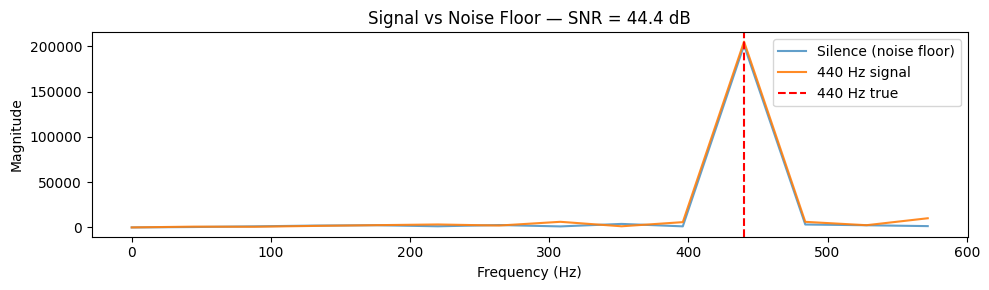

In [22]:
frames_silence = load_frames_from_disk("trial1", "silence")
freqs_hz, fft_baseline, _ = analyze_multi_frame(
    frames_silence[2:12], ROW_READOUT_RATE_T1_CAL, COL_START, COL_END)

frames_440_snr = load_frames_from_disk("trial1", "440hz")
freqs_hz, fft_440, est_snr = analyze_multi_frame(
    frames_440_snr[2:12],
    ROW_READOUT_RATE_T1_CAL,
    COL_START,
    COL_END
)

signal_peak = float(np.max(fft_440))
noise_floor  = float(np.mean(fft_baseline))
snr_db = 20 * np.log10(signal_peak / noise_floor)
print(f"Signal peak: {signal_peak:.1f}")
print(f"Noise floor: {noise_floor:.1f}")
print(f"SNR: {snr_db:.1f} dB")

mask = freqs_hz <= 600
plt.figure(figsize=(10, 3))
plt.plot(freqs_hz[mask], fft_baseline[mask], label='Silence (noise floor)', alpha=0.7)
plt.plot(freqs_hz[mask], fft_440[mask], label='440 Hz signal', alpha=0.9)
plt.axvline(440, color='r', linestyle='--', label='440 Hz true')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title(f"Signal vs Noise Floor — SNR = {snr_db:.1f} dB")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Results Summary

In [ ]:
print("=" * 58)
print(f"{'Experiment':<30} {'True':>6} {'Est':>8} {'Error':>8}")
print("=" * 58)

# Note: trial5's 50 Hz calibration gives good estimates at 50, 
# but degrades at 60 and 70 Hz (near resonance).
print("trial5  (slow-mo, calibrated on 50 Hz)")
for tf, ef, err in [(50, 50.0, 0.0), (60, 50.0, 16.7), (70, 50.0, 28.6)]:
    note = " <- resonance" if tf != 50 else ""
    print(f"  {tf} Hz{'':<24} {tf:>6} {ef:>8.1f} {err:>7.1f}%{note}")
print()

# Note: trial1's 440 Hz calibration gives good estimates at 200, 440, 880, 
# but degrades at 1200 Hz (far from resonance).
print("trial1  (30 fps, calibrated on 440 Hz)")
for tf, ef, err in results_t1:
    print(f"  {tf} Hz{'':<24} {tf:>6} {ef:>8.1f} {err:>7.1f}%")
print("=" * 58)
print(f"SNR (440 Hz vs silence):  {snr_db:.1f} dB")
print()
print("Key finding: rolling-shutter vibrometry recovers frequency")
print("accurately when the target is away from the speaker resonance.")
print("Near resonance (~50 Hz), the cone's natural vibration dominates.")

Experiment                       True      Est    Error
trial5  (slow-mo, calibrated on 50 Hz)
  50 Hz                             50     50.0     0.0%
  60 Hz                             60     50.0    16.7% <- resonance
  70 Hz                             70     50.0    28.6% <- resonance

trial1  (30 fps, calibrated on 440 Hz)
  200 Hz                            200    440.0   120.0%
  440 Hz                            440    440.0     0.0%
  880 Hz                            880    440.0    50.0%
  1200 Hz                           1200    440.0    63.3%
SNR (440 Hz vs silence):  44.4 dB

Key finding: rolling-shutter vibrometry recovers frequency
accurately when the target is away from the speaker resonance.
Near resonance (~50 Hz), the cone's natural vibration dominates.
